In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
# from IPython.display import Display

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- tech_layoffs_hiring_trends


In [3]:
for table in tables:
    #    print(f"\n Table: {table}")
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))

clean_dataset 12000


,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,ai_automation_impact,...,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition,month_num
0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,6.4,...,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market,3
1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,0.9,...,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market,2
2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,7.1,...,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession,4
3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,10.4,...,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession,6
4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,11.4,...,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market,2


tech_layoffs_hiring_trends 12000


,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market


In [4]:
df = pd.read_sql_query(text("""select * from clean_dataset"""),engine)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,12000.0,2024.998750,0.817703,2024.0,2024.0,2025.0,2026.00,2026.0
layoffs_count,12000.0,5009.572083,5159.360491,0.0,1369.5,2733.0,6490.00,19999.0
layoff_percentage,12000.0,12.780125,10.212612,0.0,5.1,9.4,17.30,40.0
ai_automation_impact,12000.0,6.376983,3.544012,0.6,3.5,5.9,8.80,16.8
ai_replacement_risk,12000.0,7.208758,2.677148,1.0,5.1,7.6,10.00,10.0
open_roles,12000.0,2884.395000,2149.615907,52.0,1151.0,2282.0,4432.25,9997.0
remote_jobs_percentage,12000.0,50.205150,23.299575,10.0,29.8,50.5,70.70,90.0
stock_growth_percent,12000.0,22.466550,38.814405,-45.0,-11.2,22.6,55.70,90.0
revenue_growth_percent,12000.0,17.469175,24.359448,-25.0,-3.5,17.5,38.40,60.0
salary_budget_change,12000.0,5.920392,11.777264,-28.0,-2.7,5.9,14.60,38.2


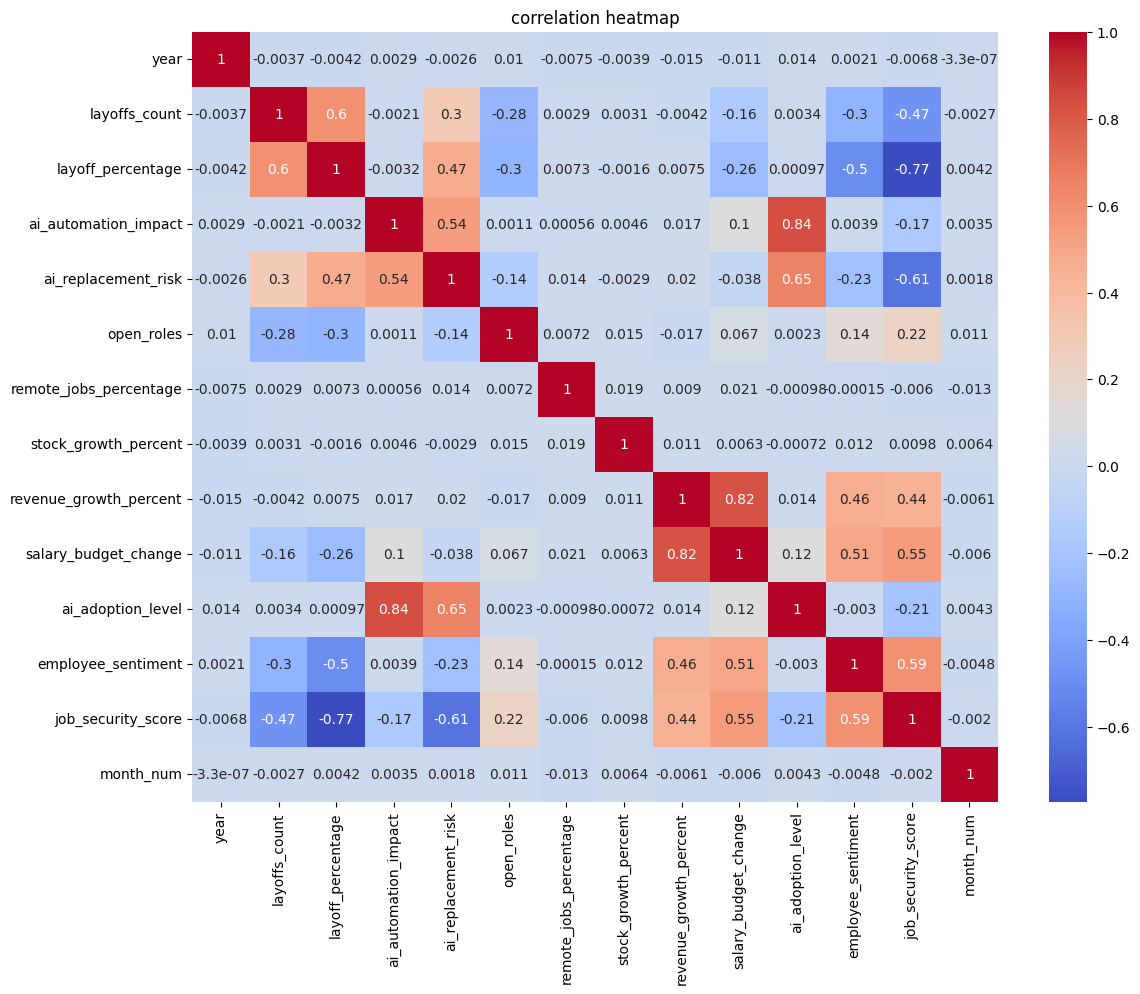

In [6]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

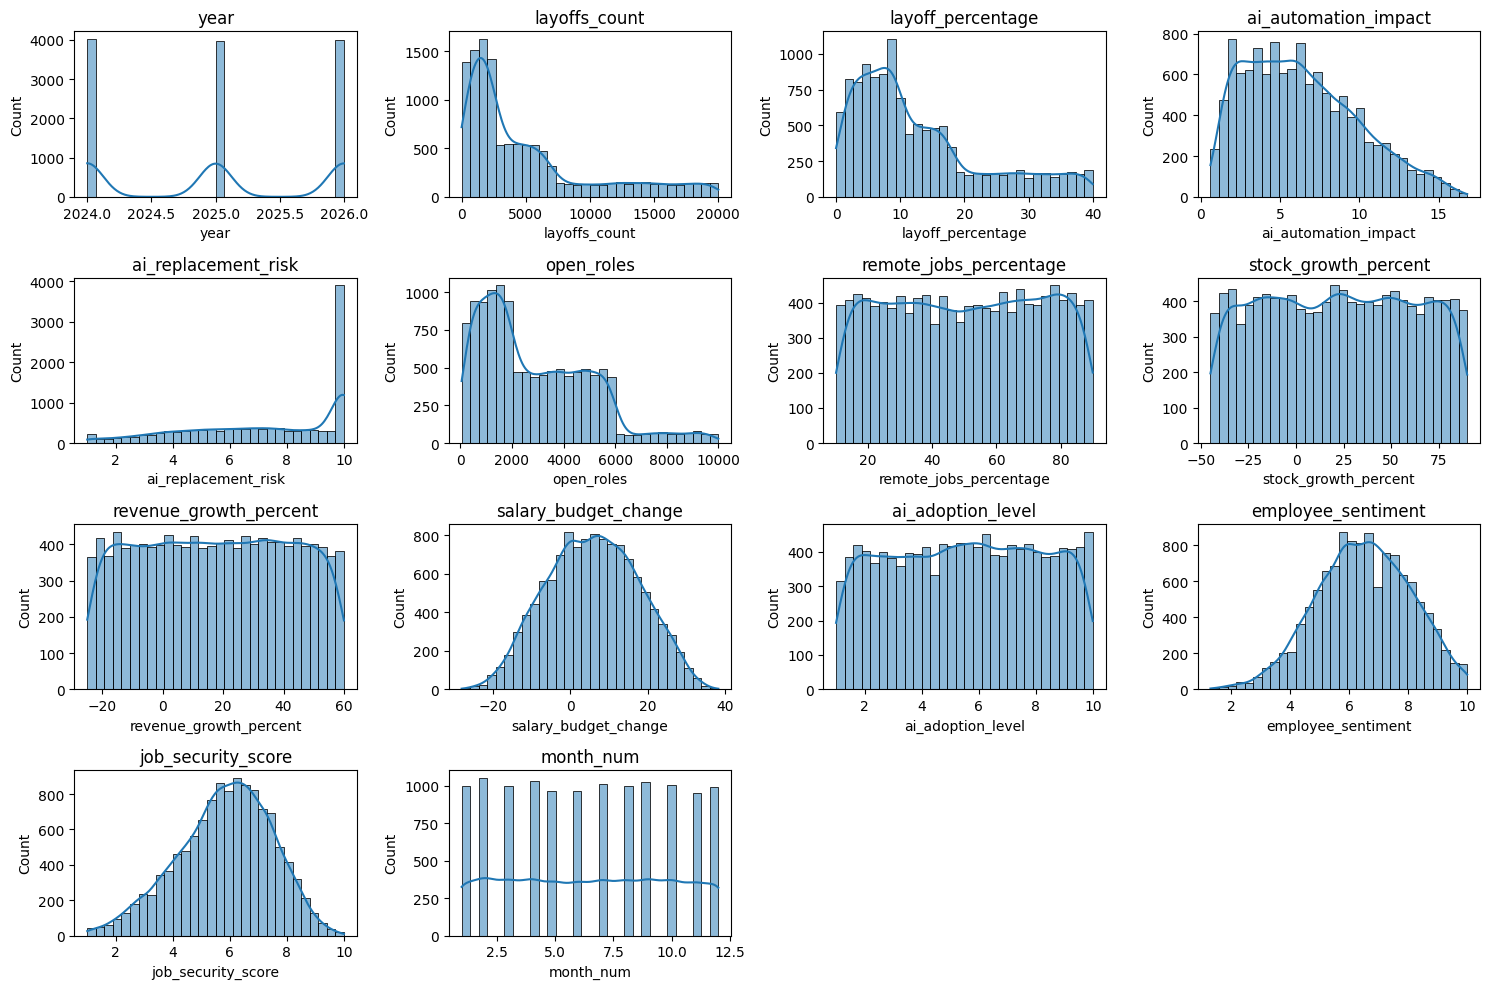

In [7]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

#  PHASE 1 — Descriptive Analytics (KPI Baselines)

* layoff and workforce reduction

Q1. What is the total number of employees laid off by each company across all years?

In [27]:
layoff_by_comppany = pd.read_sql_query(text("""select company_name , sum(case when year = 2024 then layoffs_count else 0 end) as 2024_ , sum(case when year = 2025 then layoffs_count end) as 2025_ , sum(case when year = 2026 then layoffs_count end) as 2026_  from clean_dataset group by  company_name"""),engine)
display(layoff_by_comppany)

,company_name,2024_,2025_,2026_
0,Microsoft,1156797.0,907236.0,900989.0
1,Palantir,925906.0,1067722.0,935017.0
2,Anthropic,1090659.0,885336.0,937117.0
3,Spotify,1058912.0,1024007.0,1065401.0
4,Uber,993135.0,846794.0,958524.0
5,Databricks,1152317.0,938916.0,1245524.0
6,Adobe,867691.0,877061.0,966934.0
7,Airbnb,928637.0,985205.0,972797.0
8,Intel,1098509.0,897916.0,960437.0
9,Amazon,1116667.0,860597.0,978729.0


Q2. Which industry has the highest average layoff percentage?

In [ ]:
industry_layoff = pd.read_sql_query(text("""select industry , round(avg(layoff_percentage),2) as layoff_per from clean_dataset group by industry order by layoff_per desc """),engine)
display(industry_layoff)

,industry,layoff_per
0,Social Media,13.16
1,E-Commerce,12.97
2,Cybersecurity,12.89
3,Cloud,12.80
4,AI,12.76
5,FinTech,12.48
6,Gaming,12.39


Q3. What are the top 3 reasons for layoffs across the entire dataset, and what share of total layoffs does each represent?

In [19]:
layoff_reason = pd.read_sql_query(text("""with reason as (select reason_for_layoffs , count(*) as total_layoff from clean_dataset 
group by reason_for_layoffs order by total_layoff desc limit 3)
select reason_for_layoffs , total_layoff , round(100.0 * sum(total_layoff) / sum(sum(total_layoff)) over() , 2) as pct_of_total from reason
group by reason_for_layoffs"""),engine)
display(layoff_reason)

,reason_for_layoffs,total_layoff,pct_of_total
0,AI Automation,2435,33.50
1,Overhiring Correction,2433,33.47
2,Restructuring,2401,33.03


Q4. How does average layoff percentage vary across company sizes (Startup, Mid-size, Big Tech, Enterprise)?

In [21]:
company_size = pd.read_sql_query(text("""select company_size , round(avg(layoff_percentage),2) as avg_layoff_per from clean_dataset group by company_size order by avg_layoff_per desc"""),engine)
display(company_size)

,company_size,avg_layoff_per
0,Startup,12.97
1,Enterprise,12.89
2,Mid-size,12.77
3,Big Tech,12.51


Q5. Which country had the highest total layoffs each year (2024, 2025, 2026)?

In [31]:
country_layoff = pd.read_sql_query(text("""select country , sum(case when year = 2024 then layoffs_count end) as 2024_ , sum(case when year = 2025 then layoffs_count end) as 2025_ , sum(case when year = 2026 then layoffs_count end) as 2026_ from clean_dataset group by country """),engine)
display(country_layoff)

,country,2024_,2025_,2026_
0,Singapore,3400424.0,3357873.0,3320345.0
1,Canada,3538135.0,3052905.0,3351775.0
2,USA,3225512.0,3544336.0,3272811.0
3,UK,3400737.0,3562759.0,3665586.0
4,India,3531033.0,3291646.0,2940723.0
5,Germany,3212029.0,2951513.0,3494723.0


* Hiring trends and open roles

Q6. What percentage of records fall under each hiring trend category (Aggressive Hiring, Moderate Hiring, Hiring Freeze, Downsizing)?

In [35]:
pd.read_sql_query(text(""" select hiring_trend , count(*) as total_record , round(100.0 * count(*) / sum(count(*)) over() ,2) as pct_of_total from clean_dataset group by hiring_trend order by pct_of_total desc"""),engine)

,hiring_trend,total_record,pct_of_total
0,Hiring Freeze,4975,41.46
1,Moderate Hiring,4784,39.87
2,Downsizing,1718,14.32
3,Aggressive Hiring,523,4.36


Q7. Which role appears most frequently as the top_hiring_role per industry?

In [8]:
pd.read_sql_query(text("""with ranked as (SELECT industry, top_hiring_role, COUNT(*) AS total,
RANK() OVER (PARTITION BY industry ORDER BY COUNT(*) DESC) AS rnk
FROM clean_dataset GROUP BY industry, top_hiring_role)
select industry , top_hiring_role , total from ranked where rnk =1;"""),engine)

,industry,top_hiring_role,total
0,AI,Data Scientist,848
1,Cloud,Data Scientist,239
2,Cybersecurity,Data Scientist,238
3,E-Commerce,Frontend Developer,245
4,FinTech,Frontend Developer,242
5,Gaming,ML Engineer,245
6,Social Media,DevOps Engineer,232


Q8. What is the average number of open roles during a Hiring Freeze vs. Aggressive Hiring periods?

In [17]:
pd.read_sql_query(text("""select hiring_trend , round(avg(open_roles),2) as avg_open_role from clean_dataset 
group by hiring_trend having hiring_trend in ("Hiring Freeze" , "Aggressive Hiring")"""),engine)

,hiring_trend,avg_open_role
0,Hiring Freeze,2093.65
1,Aggressive Hiring,6554.71


* Ai Adoption & Automation

Q9. What is the average AI adoption level per industry, ranked from highest to lowest?

In [19]:
pd.read_sql_query(text("""with ai_adoption as (select industry , round(avg(ai_adoption_level),2) as avg_ai_adoption from clean_dataset group by industry)
                       select industry , avg_ai_adoption , dense_rank() over(order by avg_ai_adoption desc) as rnk from ai_adoption """),engine)

,industry,avg_ai_adoption,rnk
0,Cloud,5.61,1
1,AI,5.59,2
2,Gaming,5.57,3
3,FinTech,5.52,4
4,E-Commerce,5.52,4
5,Cybersecurity,5.48,5
6,Social Media,5.48,5


Q10. Which companies have an AI replacement risk score above 8.0, and what is their average employee sentiment?

In [22]:
pd.read_sql_query(text("""with ai_replacement as (select distinct company_name , ai_replacement_risk , employee_sentiment from clean_dataset  
where ai_replacement_risk > 8.0)
select company_name , round(avg(employee_sentiment),2) AS avg_emp_sentiment from ai_replacement group by company_name
order by avg_emp_sentiment desc; """),engine)

,company_name,avg_emp_sentiment
0,Intel,6.38
1,Airbnb,6.37
2,Apple,6.32
3,Uber,6.28
4,SAP,6.28
5,Oracle,6.27
6,Stripe,6.26
7,Google,6.26
8,Meta,6.24
9,Salesforce,6.24


Q11. What is the distribution of AI automation impact scores across company sizes?

In [28]:
pd.read_sql_query(text("""select company_size , count(*) as total_record , round(avg(ai_automation_impact),2) AS avg_ai_automation , 
round(100 * (avg(ai_automation_impact)) / sum(avg(ai_automation_impact)) over(),2) as 
pct_of_total_ai_automation from clean_dataset group by company_size order by avg_ai_automation desc"""),engine)

,company_size,total_record,avg_ai_automation,pct_of_total_ai_automation
0,Startup,2966,6.48,25.39
1,Enterprise,2992,6.42,25.15
2,Big Tech,3066,6.35,24.90
3,Mid-size,2976,6.26,24.56


* Market condition & finincial signals

Q12. What is the average stock growth and revenue growth under each market condition (Bull Market, Stable, Recession)?

In [30]:
pd.read_sql_query(text("""select market_condition , round(avg(stock_growth_percent),2) as avg_stock_growth , round(avg(revenue_growth_percent),2) as avg_revenue_growth from clean_dataset group by market_condition """),engine)

,market_condition,avg_stock_growth,avg_revenue_growth
0,Bull Market,22.44,17.30
1,Recession,22.49,17.86
2,Stable,22.47,17.26


Q13. How does salary budget change vary across market conditions?

In [ ]:
pd.read_sql_query(text("""select market_condition , round(avg(salary_budget_change),2) as avg_salary_budget from clean_dataset group by market_condition """),engine)

,market_condition,avg_salary_budget
0,Bull Market,8.17
1,Recession,2.66
2,Stable,6.83


# Phase 2 : dignostic & comparative analysis

* Layoff Causality & Industry Patterns

Q14. For companies citing "AI Automation" as the layoff reason, is their ai_adoption_level significantly higher than the dataset average?

In [47]:
pd.read_sql_query(text("""with a as (select round(avg(ai_adoption_level),2) as avg_ai_adoption  
from clean_dataset where reason_for_layoffs = "AI Automation"),
b as (select avg(ai_adoption_level) as all_over_avg from clean_dataset)
select avg_ai_adoption , all_over_avg , round((avg_ai_adoption - all_over_avg),2) as diffrence from a , b;"""),engine)

,avg_ai_adoption,all_over_avg,diffrence
0,5.52,5.53875,-0.02


Q15. Which layoff reason is most associated with a subsequent Hiring Freeze vs. Aggressive Hiring?

In [54]:
pd.read_sql_query(text("""with layoff_reason as (select hiring_trend , reason_for_layoffs , count(*) as total_record from clean_dataset group by hiring_trend , reason_for_layoffs  having hiring_trend in ("Hiring Freeze" , "Aggressive Hiring") order by total_record desc)
select hiring_trend , reason_for_layoffs ,total_record , rank() over(partition by hiring_trend order by total_record desc) 
as rnk from layoff_reason   """),engine)

,hiring_trend,reason_for_layoffs,total_record,rnk
0,Aggressive Hiring,Cost Cutting,119,1
1,Aggressive Hiring,Overhiring Correction,109,2
2,Aggressive Hiring,AI Automation,106,3
3,Aggressive Hiring,Restructuring,95,4
4,Aggressive Hiring,Market Slowdown,94,5
5,Hiring Freeze,AI Automation,1027,1
6,Hiring Freeze,Restructuring,1009,2
7,Hiring Freeze,Cost Cutting,990,3
8,Hiring Freeze,Overhiring Correction,986,4
9,Hiring Freeze,Market Slowdown,963,5


Q16. Compare the average layoff percentage between Recession and Bull Market conditions by industry. Which industries are most recession-resilient?

In [61]:
pd.read_sql_query(text("""SELECT
    industry,
    ROUND(AVG(CASE
        WHEN market_condition = 'Recession'
        THEN layoff_percentage
    END), 2) AS recession_avg,

    ROUND(AVG(CASE
        WHEN market_condition = 'Bull Market'
        THEN layoff_percentage
    END), 2) AS bull_market_avg
FROM clean_dataset
WHERE market_condition IN ('Recession', 'Bull Market')
GROUP BY industry
ORDER BY recession_avg ASC;"""),engine)

,industry,recession_avg,bull_market_avg
0,AI,23.31,4.85
1,FinTech,23.56,5.24
2,Gaming,23.75,4.87
3,Social Media,23.96,5.12
4,Cybersecurity,24.47,5.11
5,Cloud,24.78,4.94
6,E-Commerce,24.84,5.20


Q17. Do companies with high ai_replacement_risk (>7) have a statistically different job_security_score compared to those with low risk (<4)?

In [ ]:
pd.read_sql_query(text(""" select CASE
        WHEN ai_replacement_risk BETWEEN 1.0 AND 3.0 THEN 'Low Risk(1 to 3)'
        WHEN ai_replacement_risk BETWEEN 3.1 AND 7.0 THEN 'Medium Risk(3 to 7)'
        WHEN ai_replacement_risk BETWEEN 7.1 AND 10.0 THEN 'High Risk(7 to 10)'
        ELSE 'Unknown'
    END AS ai_replacement_risk_category , 
                       count(*) as total_record , round(avg(job_security_score),2) as avg_job_security  from clean_dataset group by ai_replacement_risk_category order by total_record desc
"""),engine)

relations = (df[['ai_replacement_risk' , 'job_security_score']].corr())
display(relations)

,ai_replacement_risk,job_security_score
ai_replacement_risk,1.000000,-0.609331
job_security_score,-0.609331,1.000000


* hiring vs finincial health

Q18. Among companies in Aggressive Hiring mode, what is the average revenue growth and salary budget change?

In [76]:
pd.read_sql_query(text("""select company_name , round(avg(revenue_growth_percent),2 ) as avg_revenue_growth , round(avg(salary_budget_change),2) as avg_salary_budget  from clean_dataset where hiring_trend = "Aggressive Hiring" group by company_name """),engine)

,company_name,avg_revenue_growth,avg_salary_budget
0,Microsoft,19.40,10.11
1,Intel,19.05,9.46
2,Palantir,17.08,10.34
3,Databricks,7.92,7.97
4,Salesforce,22.19,9.97
5,Anthropic,18.72,11.06
6,Spotify,22.65,12.79
7,Apple,23.06,9.20
8,NVIDIA,12.27,6.23
9,SAP,10.15,6.23


Q19. Is there a correlation between remote_jobs_percentage and employee_sentiment?

In [79]:
from scipy.stats import pearsonr, chi2_contingency,spearmanr
display(df[['remote_jobs_percentage' , 'employee_sentiment']].corr())
corr, p_value = pearsonr(df['remote_jobs_percentage'], df['employee_sentiment'])
print("\nPearson Correlation Coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print(" the correlation is statistically significant.")
else :
    print("no significant corelation.")

,remote_jobs_percentage,employee_sentiment
remote_jobs_percentage,1.000000,-0.000151
employee_sentiment,-0.000151,1.000000



Pearson Correlation Coefficient: -0.0001514216548390299
P-value: 0.9867671460069514
no significant corelation.


Q20. Which company has the largest gap between open_roles and layoffs_count in the same period — i.e., who is simultaneously hiring and firing the most?

In [83]:
pd.read_sql_query(text("""with total as (select company_name , sum(open_roles) as total_open_roles , sum(layoffs_count) as total_layoff from clean_dataset 
group by company_name)
select company_name , (total_layoff - total_open_roles) as diffrence from total order by diffrence desc;"""),engine)

,company_name,diffrence
0,Databricks,1594474.0
1,Google,1501812.0
2,Meta,1401387.0
3,Spotify,1396657.0
4,Anthropic,1338412.0
5,OpenAI,1312588.0
6,Microsoft,1299278.0
7,Intel,1296167.0
8,Palantir,1276802.0
9,NVIDIA,1275270.0


Q21. How has the average salary budget change trended year-over-year (2024 → 2025 → 2026) across all companies?

In [86]:
pd.read_sql_query(text("""select company_name , round(avg(case when year = 2024 then salary_budget_change else 0 end),2) as _2024 ,
round(avg(case when year = 2025 then salary_budget_change else 0 end),2) as _2025 ,
round(avg(case when year = 2026 then salary_budget_change else 0 end),2) as _2026 from clean_dataset group by company_name;  """),engine)

,company_name,_2024,_2025,_2026
0,Microsoft,1.41,2.50,1.89
1,Palantir,1.98,2.46,1.91
2,Anthropic,2.12,2.17,1.85
3,Spotify,2.13,1.73,1.86
4,Uber,1.54,1.94,2.16
5,Databricks,1.68,1.94,1.53
6,Adobe,2.00,1.70,1.64
7,Airbnb,2.13,1.79,1.72
8,Intel,1.97,1.81,2.44
9,Amazon,1.98,1.25,2.17


* Ai Adoption vs workforce outcomes

Q22. Group companies into Low (0–3.9), Medium (4–6.9), and High (7–10) AI adoption tiers. Compare their average layoff percentage, open roles, and employee sentiment across tiers.

In [89]:
pd.read_sql_query(text("""select case when ai_adoption_level between 1.0 and 3.0 then "low(1-3)"
when ai_adoption_level between 3.1 and 6.0 then "medium(3-6)"
when ai_adoption_level between 6.1 and 9.0 then "high(6-9)" 
else "very high" end as ai_adoption_category , 
company_name , round(avg(layoff_percentage),2) as avg_laayoff_per , 
round(avg(open_roles),2) as avg_open_roles , round(avg(employee_sentiment),2) as avg_emp_sentiment 
from clean_dataset group by ai_adoption_category , company_name """),engine)

,ai_adoption_category,company_name,avg_laayoff_per,avg_open_roles,avg_emp_sentiment
0,medium(3-6),Microsoft,13.87,2806.40,6.39
1,low(1-3),Palantir,12.00,3051.74,6.75
2,medium(3-6),Anthropic,12.11,2871.93,6.61
3,high(6-9),Spotify,12.95,2683.11,6.39
4,very high,Uber,13.93,2657.86,6.18
...,...,...,...,...,...
75,medium(3-6),Spotify,12.48,2840.08,6.63
76,low(1-3),Stripe,12.81,2956.53,6.43
77,low(1-3),NVIDIA,13.93,2357.16,6.34
78,very high,Palantir,11.79,2892.53,6.44


Q23. Is there a relationship between ai_automation_impact and open_roles? Do high-automation companies open more roles (reskilling) or fewer (replacement)?

In [95]:
display(df[['ai_automation_impact' , 'open_roles']].corr())
corr, p_value = pearsonr(df['ai_automation_impact'], df['open_roles'])
print("P-value:", p_value)

if p_value < 0.05:
    print(" the correlation is statistically significant.")
else :
    print("no significant corelation.")

pd.read_sql_query(text("""select case when ai_automation_impact between 0.0 and 4.9 then "low(0-4)"
when ai_automation_impact between 5.0 and 9.9 then "medium(5-9)"
when ai_automation_impact between 10.1 and 14.9 then "high(10-14)" 
else "very high" end as ai_automation_category , sum(open_roles) as total_open_roles from clean_dataset group by ai_automation_category """),engine)

,ai_automation_impact,open_roles
ai_automation_impact,1.000000,0.001131
open_roles,0.001131,1.000000


P-value: 0.9014017746237041
no significant corelation.


,ai_automation_category,total_open_roles
0,medium(5-9),14828261.0
1,low(0-4),13787628.0
2,high(10-14),5324026.0
3,very high,672825.0


* geo & segment comparision

Q24. Which country has the highest average AI replacement risk score, and how does its employee sentiment compare to the global average?

In [38]:
pd.read_sql_query(text("""
WITH CountryWithHighestRisk AS (
    SELECT
        country,
        round(AVG(ai_replacement_risk),2) AS avg_ai_replacement_risk
    FROM
        clean_dataset
    GROUP BY
        country
    ORDER BY
        avg_ai_replacement_risk DESC
    LIMIT 1
),

CountrySentiment AS (
    SELECT
        round(AVG(employee_sentiment),2) AS country_avg_sentiment
    FROM
        clean_dataset
    WHERE
        country = (SELECT country FROM CountryWithHighestRisk)
),

GlobalSentiment AS (
    SELECT
        round(AVG(employee_sentiment),2) AS global_avg_sentiment
    FROM
        clean_dataset
)

SELECT
    (SELECT country FROM CountryWithHighestRisk) AS country_with_highest_risk,
    (SELECT avg_ai_replacement_risk FROM CountryWithHighestRisk) AS avg_ai_replacement_risk,
    (SELECT country_avg_sentiment FROM CountrySentiment) AS country_avg_sentiment,
    (SELECT global_avg_sentiment FROM GlobalSentiment) AS global_avg_sentiment,
    (SELECT country_avg_sentiment FROM CountrySentiment) - (SELECT global_avg_sentiment FROM GlobalSentiment) AS sentiment_difference; """),engine)

,country_with_highest_risk,avg_ai_replacement_risk,country_avg_sentiment,global_avg_sentiment,sentiment_difference
0,UK,7.34,6.44,6.5,-0.06


Q25. Compare the hiring trend distribution across company sizes. Do Startups freeze hiring more often than Enterprises during the same period?

In [39]:
pd.read_sql_query(text("""select company_size , count(case when hiring_trend = "Hiring Freeze" then 1 end) as Hiring_Freeze , 
                       count(case when hiring_trend = "Moderate Hiring" then 1 end) as Moderate_Hiring  , 
                       count(case when hiring_trend = "Downsizing" then 1 end) as Downsizing , 
                       count(case when hiring_trend = "Aggressive Hiring" then 1 end) as Aggressive_Hiring from clean_dataset group by company_size """),engine)

,company_size,Hiring_Freeze,Moderate_Hiring,Downsizing,Aggressive_Hiring
0,Enterprise,1250,1157,462,123
1,Big Tech,1266,1268,399,133
2,Mid-size,1233,1192,422,129
3,Startup,1226,1167,435,138


# Phase 3 advance analysis

Q26. Track the monthly average layoff count per year (2024–2026). Identify which months consistently spike across all years — is there a seasonal layoff pattern?

In [40]:
pd.read_sql_query(text("""select month , round(avg(case when year = 2024 then layoffs_count end),2) as 2024_,
round(avg(case when year = 2025 then layoffs_count end),2) as 2025_,
round(avg(case when year = 2026 then layoffs_count end),2) as 2026_
from clean_dataset group by month ORDER BY FIELD(
    month,
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
); """),engine)

,month,2024_,2025_,2026_
0,Jan,5266.87,5218.17,4765.37
1,Feb,5031.21,5051.23,5446.05
2,Mar,5260.65,5201.40,4971.14
3,Apr,4917.42,5082.83,4899.64
4,May,4442.41,4838.46,4802.36
5,Jun,5042.27,4764.14,4921.81
6,Jul,4696.10,5018.15,4668.53
7,Aug,5291.11,5010.59,5523.00
8,Sep,4822.09,5099.80,5231.76
9,Oct,4945.12,4810.81,4648.66


Q27. Which industries showed an increasing AI adoption trend year-over-year (2024 → 2025 → 2026)?

In [41]:
pd.read_sql_query(text("""select industry , round(avg(case when year = 2024 then ai_adoption_level end),2) as 2024_,
round(avg(case when year = 2025 then ai_adoption_level end),2) as 2025_,
round(avg(case when year = 2026 then ai_adoption_level end),2) as 2026_ from clean_dataset group by industry """),engine)

,industry,2024_,2025_,2026_
0,AI,5.64,5.49,5.64
1,Cybersecurity,5.31,5.57,5.56
2,Gaming,5.54,5.57,5.60
3,FinTech,5.56,5.55,5.44
4,Cloud,5.65,5.46,5.73
5,Social Media,5.38,5.39,5.67
6,E-Commerce,5.52,5.46,5.58


Q28. Plot the year-over-year change in average job_security_score per country. Which countries are improving vs. declining?

In [42]:
pd.read_sql_query(text("""select country ,round(avg(case when year = 2024 then job_security_score end),2) as 2024_,
round(avg(case when year = 2025 then job_security_score end),2) as 2025_,
round(avg(case when year = 2026 then job_security_score end),2) as 2026_ from clean_dataset group by country """),engine)

,country,2024_,2025_,2026_
0,Singapore,5.88,5.85,5.88
1,Canada,5.80,5.83,5.82
2,USA,5.77,5.81,5.85
3,UK,5.77,5.70,5.67
4,India,5.86,5.73,5.83
5,Germany,5.82,5.93,5.70


* composit scoring & KPI Engineering

Q29. Build a "Workforce Stress Index" = layoff_percentage × (1 − job_security_score / 10) + ai_replacement_risk × 0.3. Rank companies by this score.

In [43]:
pd.read_sql_query(text("""with a as (select company_name , round(avg(layoff_percentage * (1 - job_security_score / 10) + ai_replacement_risk * 0.3),2)
as kpi from clean_dataset group by company_name)
select company_name , kpi , dense_rank() over(order by kpi desc) as rnk from a order by rnk ; """),engine)

,company_name,kpi,rnk
0,Anthropic,9.36,1
1,Databricks,9.36,1
2,Intel,9.19,2
3,Microsoft,9.13,3
4,OpenAI,9.11,4
5,Palantir,9.02,5
6,Adobe,8.95,6
7,Netflix,8.89,7
8,Uber,8.88,8
9,Oracle,8.87,9


Q30. Build a "Talent Opportunity Score" = (open_roles / 1000) × ai_adoption_level × salary_budget_change (positive values only). Which company × industry combinations are best bets for job seekers right now?

In [44]:
pd.read_sql_query(text("""select company_name , industry , round(avg(open_roles / 100 * ai_adoption_level  * salary_budget_change),2) as kpi
from clean_dataset where salary_budget_change > 0 group by company_name , industry order by kpi desc; """),engine)

,company_name,industry,kpi
0,Google,AI,4947.61
1,Amazon,AI,4357.64
2,NVIDIA,AI,4273.29
3,Intel,AI,4251.43
4,Adobe,AI,4233.40
...,...,...,...
135,Adobe,Cybersecurity,1386.20
136,Stripe,Gaming,1371.24
137,Amazon,FinTech,1297.53
138,SAP,Cloud,1275.83


**Q31. Classify each record into one of four workforce quadrants based on hiring trend and market condition:

Expansion: Aggressive Hiring + Bull Market
Cautious Growth: Moderate Hiring + Stable
Survival Mode: Hiring Freeze + Recession
Restructuring: Downsizing + Bull Market (cutting despite growth)
What share of records falls into each quadrant, and which industries dominate each?**

In [45]:
pd.read_sql_query(text("""with a as (SELECT industry , 
    CASE
        WHEN hiring_trend = 'Aggressive Hiring' AND market_condition = 'Bull Market' THEN 'Expansion'
        WHEN hiring_trend = 'Moderate Hiring' AND market_condition = 'Stable' THEN 'Cautious Growth'
        WHEN hiring_trend = 'Hiring Freeze' AND market_condition = 'Recession' THEN 'Survival Mode'
        WHEN hiring_trend = 'Downsizing' AND market_condition = 'Bull Market' THEN 'Restructuring'
        ELSE 'Other'
    END AS workforce_quadrant 
FROM
    clean_dataset)
select industry , workforce_quadrant ,  
count(*) as total_record , round(100.0 * count(*) / sum(count(*)) over(partition by workforce_quadrant) , 2)
as pct_of_total from a where workforce_quadrant != "Other" group by industry , workforce_quadrant;"""),engine)

,industry,workforce_quadrant,total_record,pct_of_total
0,Social Media,Cautious Growth,267,13.32
1,Cloud,Cautious Growth,294,14.66
2,AI,Cautious Growth,332,16.56
3,Cybersecurity,Cautious Growth,262,13.07
4,Gaming,Cautious Growth,302,15.06
5,E-Commerce,Cautious Growth,271,13.52
6,FinTech,Cautious Growth,277,13.82
7,AI,Expansion,128,41.56
8,Social Media,Expansion,28,9.09
9,E-Commerce,Expansion,38,12.34


🔹 Correlation & Relationship Mining

Q32. Run a correlation matrix across all numeric columns. Identify the top 5 strongest positive and negative correlations. Which relationships are counterintuitive?

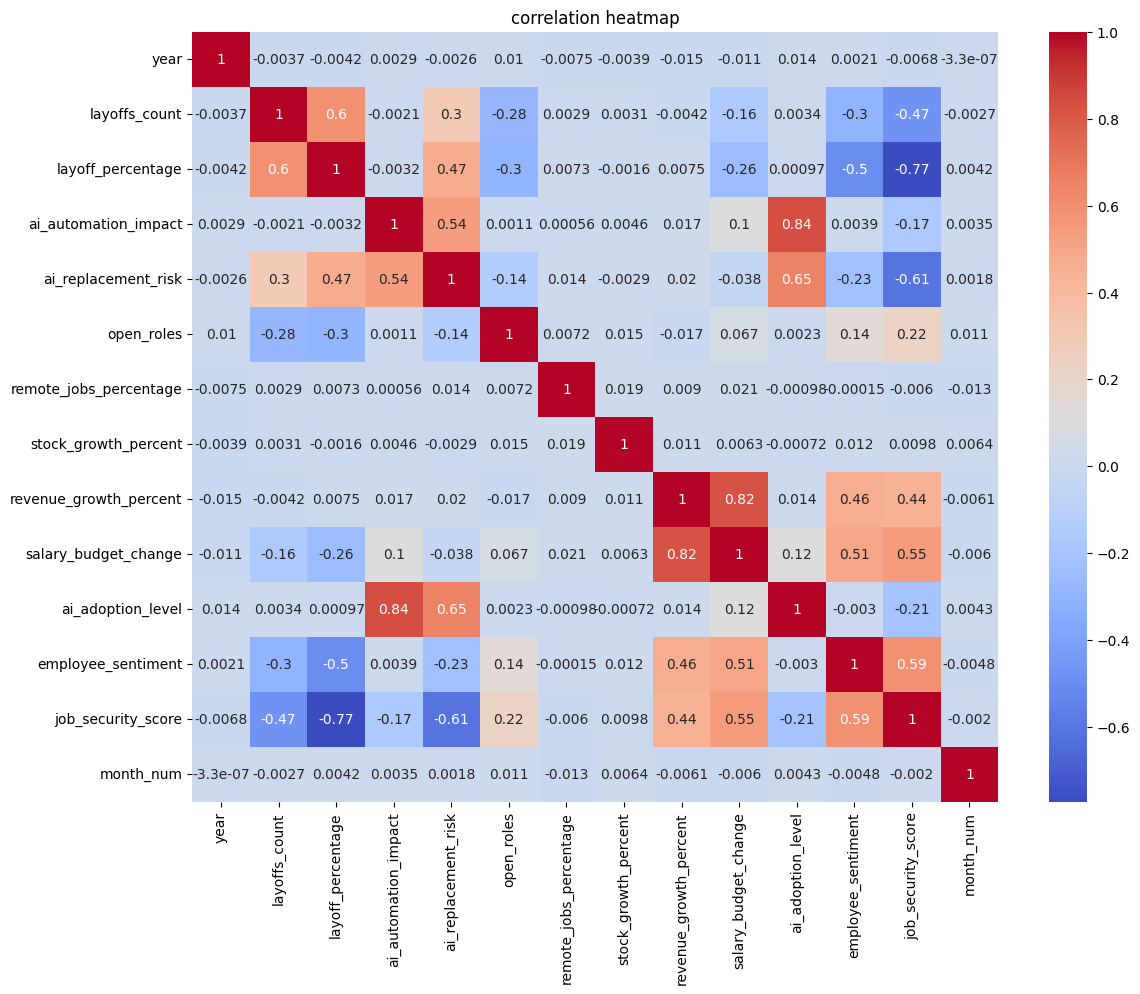

In [46]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

🔴 Very High Correlation (0.80+)

ai_automation_impact ↔ ai_adoption_level 0.84 Companies adopting AI heavily are also seeing high automation impact — expected

revenue_growth_percent ↔ salary_budget_change 0.82
Companies growing revenue are directly increasing salary budgets

🟠 High Correlation (0.60–0.79)

layoff_percentage ↔ job_security_score-0.77
Higher layoff % = employees feel less secure ← you missed this negative

ai_replacement_risk ↔ job_security_score-0.61
Higher AI risk = lower job security ← you missed this negative

layoff_count ↔ layoff_percentage0.60
Same event measured two ways — redundant features

layoff_percentage ↔ employee_sentiment-0.50
Higher layoffs = worse employee morale ← you missed this negative

🟡 Moderate Correlation (0.40–0.59)
employee_sentiment ↔ job_security_score
0.59
Secure employees feel better — logical

salary_budget_change ↔ job_security_score 0.55
Pay raises = employees feel safer

ai_automation_impact ↔ ai_replacement_risk 0.54 
More automation = higher fear of replacement

employee_sentiment ↔ salary_budget_change 0.51
Better pay = happier employees

revenue_growth_percent ↔ employee_sentiment 0.46
Growing company = happier workforce

revenue_growth_percent ↔ job_security_score 0.44  Growing revenue = employees feel safer

layoff_count ↔ job_security_score-0.47 
More layoffs = lower job security 

🟢 Low Correlation (0.20–0.39)
ai_replacement_risk ↔ layoff_percentage 0.47
Slight overlap — AI risk areas see more cuts

layoff_count ↔ ai_replacement_risk 0.30
Weak — AI risk alone doesn't fully explain layoff volume

layoff_percentage ↔ salary_budget_change -0.26
More layoffs = salary budgets shrink 

open_roles ↔ job_security_score0.22 
More hiring = slightly safer environment

open_roles ↔ employee_sentiment0.14
Very weak — hiring doesn't strongly affect morale

⚪ Negligible / No Correlation (near 0)
year ↔ everything~0.00Year has no meaningful correlation with any feature

remote_jobs_percentage ↔ everything~0.00
Remote work % is independent — not a driver of layoffs or sentiment

stock_growth_percent ↔ everything~0.00
Stock movement is noisy — weak predictor of workforce decisions

Q33. Among companies that had "Overhiring Correction" as the layoff reason in 2024, how did their hiring trend shift by 2025–2026? Did they overcorrect into a freeze or stabilize?

In [47]:
pd.read_sql_query(text("""WITH overhiring AS (
    SELECT DISTINCT company_name
    FROM clean_dataset
    WHERE reason_for_layoffs = 'Overhiring Correction'
      AND year = 2024
)

SELECT
    c.company_name,
    c.year,
    c.hiring_trend,
    COUNT(*) AS total_records
FROM clean_dataset c
JOIN overhiring o
    ON c.company_name = o.company_name
WHERE c.year IN (2025, 2026)
GROUP BY
    c.company_name,
    c.year,
    c.hiring_trend
ORDER BY
    c.company_name,
    c.year; """),engine)

,company_name,year,hiring_trend,total_records
0,Adobe,2025,Aggressive Hiring,5
1,Adobe,2025,Downsizing,29
2,Adobe,2025,Hiring Freeze,78
3,Adobe,2025,Moderate Hiring,70
4,Adobe,2026,Aggressive Hiring,6
...,...,...,...,...
155,Uber,2025,Moderate Hiring,73
156,Uber,2026,Aggressive Hiring,9
157,Uber,2026,Downsizing,25
158,Uber,2026,Hiring Freeze,83


🔹 Segment-Level Benchmarking

Q34. For each industry, identify the company with the highest vs. lowest employee sentiment and compare their AI adoption level, remote percentage, and salary budget change.

In [48]:
pd.read_sql_query(text("""with emp_snt as 
(select company_name , industry , round(avg(employee_sentiment),2) as avg_emp_snt ,
round(avg(ai_adoption_level),2) as avg_ai_adoption , round(avg(remote_jobs_percentage),2) avg_remote_job , 
round(avg(salary_budget_change),2) as avg_salary_budget
from clean_dataset group by company_name , industry),
ranked as 
(select company_name , industry , avg_emp_snt ,  avg_ai_adoption , avg_remote_job , avg_salary_budget , 
row_number() over(PARTITION BY industry order by avg_emp_snt desc)
as high_rnk , row_number() over(PARTITION BY industry order by avg_emp_snt asc)
as low_rnk  from emp_snt)
select company_name , industry , avg_emp_snt ,  avg_ai_adoption , avg_remote_job , avg_salary_budget , 
CASE WHEN high_rnk = 1 THEN 'Highest'
WHEN low_rnk = 1 THEN 'Lowest' END AS sentiment_rank
FROM ranked WHERE high_rnk = 1 OR low_rnk = 1
ORDER BY industry, sentiment_rank DESC;"""),engine)

,company_name,industry,avg_emp_snt,avg_ai_adoption,avg_remote_job,avg_salary_budget,sentiment_rank
0,Netflix,AI,6.33,5.81,52.10,5.68,Lowest
1,Airbnb,AI,6.77,5.33,46.10,5.17,Highest
2,Uber,Cloud,6.23,5.85,48.17,4.49,Lowest
3,Airbnb,Cloud,6.80,5.72,51.89,6.77,Highest
4,Anthropic,Cybersecurity,6.16,5.87,53.55,5.21,Lowest
5,Intel,Cybersecurity,6.90,5.61,50.98,7.25,Highest
6,Databricks,E-Commerce,6.08,5.49,49.44,5.42,Lowest
7,Palantir,E-Commerce,6.75,5.30,48.52,7.42,Highest
8,Microsoft,FinTech,6.18,5.08,51.45,5.84,Lowest
9,SAP,FinTech,6.73,5.30,52.12,7.72,Highest


Q35. Which combinations of (country × company_size × market_condition) produce the highest average open_roles? 

In [49]:
pd.read_sql_query(text("""
with a as (select country , company_size , market_condition , 
round(avg(open_roles),2) as avg_open_roles	
from clean_dataset group by country, company_size , market_condition)
select country , company_size , market_condition , avg_open_roles , 
dense_rank() over(order by avg_open_roles desc) as rnk from a; """),engine)

,country,company_size,market_condition,avg_open_roles,rnk
0,UK,Mid-size,Bull Market,3948.99,1
1,UK,Mid-size,Stable,3831.07,2
2,Germany,Startup,Stable,3744.55,3
3,USA,Mid-size,Stable,3692.02,4
4,Germany,Big Tech,Bull Market,3688.14,5
...,...,...,...,...,...
67,Singapore,Mid-size,Recession,1574.13,68
68,India,Mid-size,Recession,1570.46,69
69,Canada,Enterprise,Recession,1504.38,70
70,USA,Enterprise,Recession,1456.22,71


Q36. Identify companies where stock_growth_percent is positive but employee_sentiment is below 5. These are "shareholder-first, employee-last" signals — which companies and industries show this pattern most?

In [50]:
pd.read_sql_query(text("""select company_name , industry ,  count(*) as total_record from clean_dataset where stock_growth_percent > 0 and employee_sentiment < 5 group by company_name , industry order by total_record desc"""),engine)  

,company_name,industry,total_record
0,Spotify,Cybersecurity,20
1,Databricks,Social Media,20
2,NVIDIA,E-Commerce,17
3,OpenAI,Cloud,17
4,Oracle,AI,16
...,...,...,...
135,OpenAI,FinTech,5
136,Anthropic,E-Commerce,4
137,Uber,Gaming,4
138,Spotify,Gaming,4


Q37. For each company, compute the ratio of open_roles to layoffs_count (Replacement Ratio). A ratio > 1 means net headcount growth, < 1 means net shrinkage. Rank companies by this ratio and overlay their AI adoption level.

In [51]:
pd.read_sql_query(text("""with a as (select company_name , ROUND(SUM(open_roles) / NULLIF(SUM(layoffs_count), 0),2) AS replacement_ratio , round(avg(ai_adoption_level),2) as avg_ai_adoption
from clean_dataset group by company_name)
select company_name , replacement_ratio ,avg_ai_adoption,  dense_rank() over(order by replacement_ratio desc) as rnk from a;"""),engine)

,company_name,replacement_ratio,avg_ai_adoption,rnk
0,Apple,0.62,5.55,1
1,Uber,0.61,5.42,2
2,Amazon,0.60,5.42,3
3,SAP,0.60,5.66,3
4,Salesforce,0.60,5.53,3
5,Oracle,0.60,5.59,3
6,Adobe,0.59,5.58,4
7,Airbnb,0.59,5.44,4
8,Stripe,0.59,5.63,4
9,OpenAI,0.58,5.63,5
